# EXPLORATORY DATA ANALYSIS #

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import chi2_contingency

In [2]:
# Load Dataset
df=pd.read_stata("18NGIR7BFL.DTA")
print('Dataset Loaded Successfully!!!')

Dataset Loaded Successfully!!!


In [3]:
print(f"Shape: {df.shape}")

Shape: (41821, 5394)


In [4]:
# see the first 3 rows
df.head(3)

,caseid,v000,v001,v002,v003,v004,v005,v006,v007,v008,...,s434k_3,s434k_4,s434k_5,s434k_6,s434l_1,s434l_2,s434l_3,s434l_4,s434l_5,s434l_6
0,1 1 2,NG7,1,1,2,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 6 4,NG7,1,6,4,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 11 1,NG7,1,11,1,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41821 entries, 0 to 41820
Columns: 5394 entries, caseid to s434l_6
dtypes: category(4854), float64(478), int16(15), int32(4), int8(32), object(11)
memory usage: 359.3+ MB


In [6]:
# List of variables we need for the analysis
key_vars = ['v005',  # Sample weight
            'v012',  # Age
            'v024',  # Region
            'v025',  # Urban/Rural
            'v106',  # Education
            'v190',  # Wealth index
            'v201',  # Parity (total children ever born)
            'm14_1', # ANC visits (most recent birth)
            'm3a_1', 'm3b_1', 'm3c_1' # Delivery assistance (most recent birth)
            ]

# copy of the dataset
df_clean = df[key_vars].copy()
print(f" New Working Dataset Shape: {df_clean.shape}")
print("\nMissing values per column:")
print(df_clean.isnull().sum())

# see first 3 rows
df_clean.head(3)

 New Working Dataset Shape: (41821, 11)

Missing values per column:
v005         0
v012         0
v024         0
v025         0
v106         0
v190         0
v201         0
m14_1    20029
m3a_1    20029
m3b_1    20029
m3c_1    20029
dtype: int64


,v005,v012,v024,v025,v106,v190,v201,m14_1,m3a_1,m3b_1,m3c_1
0,1335530,40,north central,urban,higher,richest,3,6.0,yes,no,no
1,1335530,16,north central,urban,secondary,richest,0,NaN,NaN,NaN,NaN
2,1335530,37,north central,urban,higher,richest,3,5.0,yes,yes,no


In [7]:
# understanding each variable/ explore key variables

# Check your delivery assistance variables (most recent birth only)
print("=== m3a_1 (Doctor assisted): ===")
print(df_clean['m3a_1'].value_counts(dropna=False))

print("\n=== m3b_1 (Nurse/Midwife assisted): ===")
print(df_clean['m3b_1'].value_counts(dropna=False))

print("\n=== m3c_1 (Auxiliary Midwife assisted): ===")
print(df_clean['m3c_1'].value_counts(dropna=False))

print("\n=== m14_1 (ANC visits - most recent birth): ===")
print(df_clean['m14_1'].value_counts(dropna=False).sort_index())


print("\n=== v106 (Education): ===")
print(df_clean['v106'].value_counts(dropna=False))

print("\n=== v025 (Residence): ===")
print(df_clean['v025'].value_counts(dropna=False))

print("\n=== v190 (Wealth): ===")
print(df_clean['v190'].value_counts(dropna=False))

print("\n=== v024 (Region): ===")
print(df_clean['v024'].value_counts(dropna=False))

=== m3a_1 (Doctor assisted): ===
m3a_1
NaN    20029
no     19862
yes     1930
Name: count, dtype: int64

=== m3b_1 (Nurse/Midwife assisted): ===
m3b_1
NaN    20029
no     13630
yes     8162
Name: count, dtype: int64

=== m3c_1 (Auxiliary Midwife assisted): ===
m3c_1
no     21119
NaN    20029
yes      673
Name: count, dtype: int64

=== m14_1 (ANC visits - most recent birth): ===
m14_1
no antenatal visits     5365
1.0                      583
2.0                      968
3.0                     2242
4.0                     2716
5.0                     2344
6.0                     2095
7.0                     1055
8.0                     1079
9.0                      443
10.0                     806
11.0                     160
12.0                     472
13.0                      80
14.0                     113
15.0                     231
16.0                     166
17.0                      56
18.0                     115
19.0                      33
20.0                     343
don'

In [8]:
# filter to women who had a birth
# Keep only women who have data for most recent birth
df_analysis = df_clean.dropna(subset=['m3a_1']).copy()

print(f"Women with recent birth data: {len(df_analysis)}")
print(f"Women dropped (no recent birth): {len(df_clean) - len(df_analysis)}")

Women with recent birth data: 21792
Women dropped (no recent birth): 20029


In [9]:
# Create the SBA outcome variable
# SBA = 1 if doctor OR nurse/midwife OR auxiliary midwife was present
# SBA = 0 if none of the above were present

df_analysis['SBA'] = (
    (df_analysis['m3a_1'] == 'yes') |   # doctor
    (df_analysis['m3b_1'] == 'yes') |   # nurse/midwife
    (df_analysis['m3c_1'] == 'yes')     # auxiliary midwife
).astype(int)

# Verify it worked
print("SBA Distribution:")
print(df_analysis['SBA'].value_counts())
print(f"\nSBA Rate: {df_analysis['SBA'].mean() * 100:.1f}%")

SBA Distribution:
SBA
0    11997
1     9795
Name: count, dtype: int64

SBA Rate: 44.9%


In [10]:
# Apply DHS sampling weight
# DHS weights are stored as integers, so must divide by 1,000,000
df_analysis['weight'] = df_analysis['v005'] / 1000000

print("Weight sample stats:")
print(df_analysis['weight'].describe())

Weight sample stats:
count    21792.000000
mean         1.005464
std          0.651710
min          0.103280
25%          0.612702
50%          0.877884
75%          1.235807
max         13.411626
Name: weight, dtype: float64


In [11]:
# ANC visits: recode into binary (< 4 visits vs ≥ 4 visits)
# WHO recommends at least 4 ANC visits
df_analysis['anc_4plus'] = df_analysis['m14_1'].apply(
    lambda x: 1 if isinstance(x, float) and x >= 4 else 0 if (isinstance(x, float) and x < 4) or x == 'no antenatal visits' else np.nan)

print("ANC 4+ visits:")
print(df_analysis['anc_4plus'].value_counts(dropna=False))

ANC 4+ visits:
anc_4plus
1.0    12307
0.0     9158
NaN      327
Name: count, dtype: int64


In [12]:
# Age group: recode continuous age into categories
df_analysis['age_group'] = pd.cut(
    df_analysis['v012'],
    bins=[14, 19, 24, 29, 34, 39, 49],
    labels=['15-19', '20-24', '25-29', '30-34', '35-39', '40-49']
)

print("Age groups:")
print(df_analysis['age_group'].value_counts().sort_index())

Age groups:
age_group
15-19    1193
20-24    4206
25-29    5617
30-34    4670
35-39    3622
40-49    2484
Name: count, dtype: int64


In [13]:
# Parity: recode into categories 
df_analysis['parity_cat'] = pd.cut(
    df_analysis['v201'],
    bins=[-1, 1, 3, 5, 100],
    labels=['1', '2-3', '4-5', '6+']
)

print("Parity categories:")
print(df_analysis['parity_cat'].value_counts().sort_index())

Parity categories:
parity_cat
1      3715
2-3    7106
4-5    5252
6+     5719
Name: count, dtype: int64


In [14]:
# Final check to see full analytic dataset
print("\n=== FINAL ANALYTIC DATASET ===")
print(f"Total women: {len(df_analysis)}")
print(f"\nSBA (outcome):\n{df_analysis['SBA'].value_counts()}")
print("\nMissing values summary:")
print(df_analysis[['SBA', 'anc_4plus', 'age_group', 'parity_cat', 'v106', 'v190', 'v025', 'v024']].isnull().sum())


=== FINAL ANALYTIC DATASET ===
Total women: 21792

SBA (outcome):
SBA
0    11997
1     9795
Name: count, dtype: int64

Missing values summary:
SBA             0
anc_4plus     327
age_group       0
parity_cat      0
v106            0
v190            0
v025            0
v024            0
dtype: int64


# DESCRIPTIVE STATISTICS

In [15]:
# Function to calculate frequency and percentage for our categorical variables
def describe_categorical(df, column, label):
    counts = df[column].value_counts(dropna=False)
    percent = df[column].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({'n': counts, '%': percent.round(1)})
    print(f"\n=== {label} === ")
    print(result)
    return result

# Run for each variable
describe_categorical(df_analysis, 'v025', 'Residence (Urban/Rural)')
describe_categorical(df_analysis, 'v106', 'Education Level')
describe_categorical(df_analysis, 'v190', 'Wealth Index')
describe_categorical(df_analysis, 'v024', 'Region')
describe_categorical(df_analysis, 'age_group', 'Age Group')
describe_categorical(df_analysis, 'parity_cat', 'Parity')
describe_categorical(df_analysis, 'anc_4plus', 'ANC 4+ Visits')
describe_categorical(df_analysis, 'SBA', 'Skilled Birth Attendance (Outcome)')


=== Residence (Urban/Rural) === 
           n     %
v025              
rural  14082  64.6
urban   7710  35.4

=== Education Level === 
                 n     %
v106                    
no education  9527  43.7
secondary     7064  32.4
primary       3410  15.6
higher        1791   8.2

=== Wealth Index === 
            n     %
v190               
poorest  5025  23.1
poorer   4905  22.5
middle   4586  21.0
richer   4025  18.5
richest  3251  14.9

=== Region === 
                  n     %
v024                     
north west     6309  29.0
north east     4506  20.7
north central  3875  17.8
south west     2563  11.8
south east     2365  10.9
south south    2174  10.0

=== Age Group === 
              n     %
age_group            
25-29      5617  25.8
30-34      4670  21.4
20-24      4206  19.3
35-39      3622  16.6
40-49      2484  11.4
15-19      1193   5.5

=== Parity === 
               n     %
parity_cat            
2-3         7106  32.6
6+          5719  26.2
4-5         5252  24.

,n,%
SBA,,
0,11997,55.1
1,9795,44.9


In [16]:
# For continuous variables: mean, median, std, min, max
continuous_vars = {
    'v012': 'Age (years)',
    'v201': 'Parity (total children)'
}

for var, label in continuous_vars.items():
    data = df_analysis[var]
    print(f"\n=== {label} ===")
    print(f"  Mean:    {data.mean():.1f}")
    print(f"  Median:  {data.median():.1f}")
    print(f"  Std Dev: {data.std():.1f}")
    print(f"  Min:     {data.min():.0f}")
    print(f"  Max:     {data.max():.0f}")


=== Age (years) ===
  Mean:    29.7
  Median:  29.0
  Std Dev: 7.2
  Min:     15
  Max:     49

=== Parity (total children) ===
  Mean:    4.1
  Median:  4.0
  Std Dev: 2.6
  Min:     1
  Max:     17


In [17]:
print("=== SBA Rate by Key Predictors ===\n")

predictors = {
    'v025': 'Residence',
    'v106': 'Education',
    'v190': 'Wealth Index',
    'v024': 'Region',
    'parity_cat': 'Parity Category ',
    'age_group': 'Age Group',
    'anc_4plus': 'ANC 4+ Visits'
}

for var, label in predictors.items():
    print(f"\n=== SBA Rate by {label} ===")
    
    # Group by the predictor, calculate SBA mean (= proportion) per group
    sba_by_group = df_analysis.groupby(var)['SBA'].agg(['sum', 'count', 'mean'])
    sba_by_group.columns = ['Skilled births', 'Total', 'SBA Rate']
    sba_by_group['SBA Rate %'] = (sba_by_group['SBA Rate'] * 100).round(1)
    
    print(sba_by_group[['Skilled births', 'Total', 'SBA Rate %']])

=== SBA Rate by Key Predictors ===


--- SBA Rate by Residence ---
       Skilled births  Total  SBA Rate %
v025                                    
urban            5275   7710        68.4
rural            4520  14082        32.1

--- SBA Rate by Education ---
              Skilled births  Total  SBA Rate %
v106                                           
no education            1499   9527        15.7
primary                 1639   3410        48.1
secondary               5004   7064        70.8
higher                  1653   1791        92.3

--- SBA Rate by Wealth Index ---
         Skilled births  Total  SBA Rate %
v190                                      
poorest             615   5025        12.2
poorer             1287   4905        26.2
middle             2280   4586        49.7
richer             2777   4025        69.0
richest            2836   3251        87.2

--- SBA Rate by Region ---
               Skilled births  Total  SBA Rate %
v024                                  

C:\Users\Ugoeze\AppData\Local\Temp\ipykernel_18976\2270515844.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sba_by_group = df_analysis.groupby(var)['SBA'].agg(['sum', 'count', 'mean'])
C:\Users\Ugoeze\AppData\Local\Temp\ipykernel_18976\2270515844.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sba_by_group = df_analysis.groupby(var)['SBA'].agg(['sum', 'count', 'mean'])
C:\Users\Ugoeze\AppData\Local\Temp\ipykernel_18976\2270515844.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavio

C:\Users\Ugoeze\AppData\Local\Temp\ipykernel_18976\2908218193.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wealth_data = df_analysis.groupby('v190')['SBA'].mean() * 100
C:\Users\Ugoeze\AppData\Local\Temp\ipykernel_18976\2908218193.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_data = df_analysis.groupby('v106')['SBA'].mean() * 100
C:\Users\Ugoeze\AppData\Local\Temp\ipykernel_18976\2908218193.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

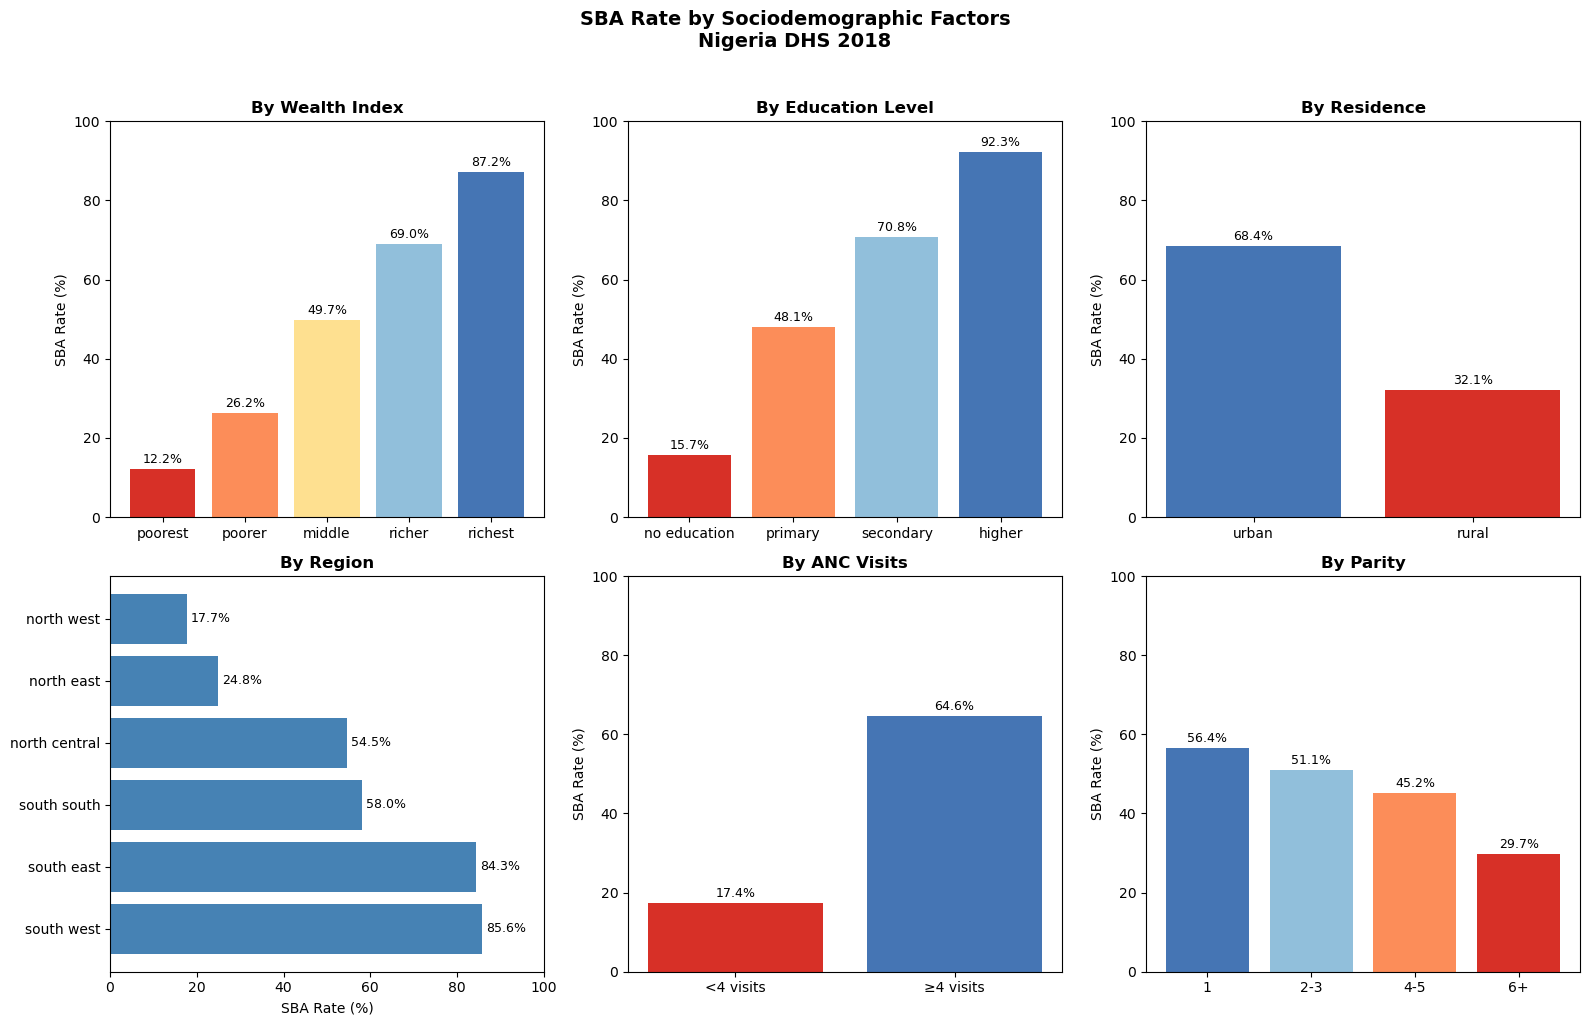

Chart saved!


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SBA Rate by Sociodemographic Factors\nNigeria DHS 2018', 
             fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: Wealth ---
wealth_order = ['poorest', 'poorer', 'middle', 'richer', 'richest']
wealth_data = df_analysis.groupby('v190')['SBA'].mean() * 100
wealth_data = wealth_data.reindex(wealth_order)

axes[0,0].bar(wealth_data.index, wealth_data.values, color=['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4'])
axes[0,0].set_title('By Wealth Index', fontweight='bold')
axes[0,0].set_ylabel('SBA Rate (%)')
axes[0,0].set_ylim(0, 100)
for i, v in enumerate(wealth_data.values):
    axes[0,0].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)

# --- Plot 2: Education ---
edu_order = ['no education', 'primary', 'secondary', 'higher']
edu_data = df_analysis.groupby('v106')['SBA'].mean() * 100
edu_data = edu_data.reindex(edu_order)

axes[0,1].bar(edu_data.index, edu_data.values, color=['#d73027','#fc8d59','#91bfdb','#4575b4'])
axes[0,1].set_title('By Education Level', fontweight='bold')
axes[0,1].set_ylabel('SBA Rate (%)')
axes[0,1].set_ylim(0, 100)
for i, v in enumerate(edu_data.values):
    axes[0,1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)

# --- Plot 3: Residence ---
res_data = df_analysis.groupby('v025')['SBA'].mean() * 100

axes[0,2].bar(res_data.index, res_data.values, color=['#4575b4', '#d73027'])
axes[0,2].set_title('By Residence', fontweight='bold')
axes[0,2].set_ylabel('SBA Rate (%)')
axes[0,2].set_ylim(0, 100)
for i, v in enumerate(res_data.values):
    axes[0,2].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)

# --- Plot 4: Region ---
region_data = df_analysis.groupby('v024')['SBA'].mean() * 100
region_data = region_data.sort_values(ascending=False)

axes[1,0].barh(region_data.index, region_data.values, color='steelblue')
axes[1,0].set_title('By Region', fontweight='bold')
axes[1,0].set_xlabel('SBA Rate (%)')
axes[1,0].set_xlim(0, 100)
for i, v in enumerate(region_data.values):
    axes[1,0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

# --- Plot 5: ANC Visits ---
anc_labels = {0.0: '<4 visits', 1.0: '≥4 visits'}
anc_data = df_analysis.groupby('anc_4plus')['SBA'].mean() * 100

axes[1,1].bar([anc_labels[k] for k in anc_data.index], anc_data.values, 
              color=['#d73027', '#4575b4'])
axes[1,1].set_title('By ANC Visits', fontweight='bold')
axes[1,1].set_ylabel('SBA Rate (%)')
axes[1,1].set_ylim(0, 100)
for i, v in enumerate(anc_data.values):
    axes[1,1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)

# --- Plot 6: Parity ---
parity_order = ['1', '2-3', '4-5', '6+']
parity_data = df_analysis.groupby('parity_cat')['SBA'].mean() * 100
parity_data = parity_data.reindex(parity_order)

axes[1,2].bar(parity_data.index, parity_data.values, color=['#4575b4','#91bfdb','#fc8d59','#d73027'])
axes[1,2].set_title('By Parity', fontweight='bold')
axes[1,2].set_ylabel('SBA Rate (%)')
axes[1,2].set_ylim(0, 100)
for i, v in enumerate(parity_data.values):
    axes[1,2].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('SBA_descriptive_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# INFERENTIAL STATISTICS #

In [20]:
print("=" * 65)
print("BIVARIATE ANALYSIS: Chi-Square Tests for Association with SBA")
print("=" * 65)

# Variables to test
test_vars = {
    'v025':      'Residence (Urban/Rural)',
    'v106':      'Education Level',
    'v190':      'Wealth Index',
    'v024':      'Region',
    'age_group': 'Age Group',
    'parity_cat':'Parity',
    'anc_4plus': 'ANC 4+ Visits'
}

results = []  # we'll store results here for a summary table

for var, label in test_vars.items():
    
    # Step 1: Build a contingency table (crosstab)
    ct = pd.crosstab(df_analysis[var], df_analysis['SBA'])
    
    # Step 2: Run chi-square test
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # Step 3: Determine significance
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "NS"))
    
    # Step 4: Print result
    print(f"\n{label}")
    print(f"  Chi-square = {chi2:.2f} | df = {dof} | p-value = {p:.4f} {sig}")
    print(f"  Contingency table:")
    print(ct)
    
    # Store for summary
    results.append({'Variable': label, 'Chi2': round(chi2,2), 'df': dof, 
                    'p-value': round(p,4), 'Significance': sig})

# Summary table
print("\n\n" + "=" * 65)
print("SUMMARY: Chi-Square Results")
print("=" * 65)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  NS = Not Significant")

### 🧠 Understanding Every Part of This Code

pd.crosstab(df_analysis[var], df_analysis['SBA'])

BIVARIATE ANALYSIS: Chi-Square Tests for Association with SBA

Residence (Urban/Rural)
  Chi-square = 2654.54 | df = 1 | p-value = 0.0000 ***
  Contingency table:
SBA       0     1
v025             
urban  2435  5275
rural  9562  4520

Education Level
  Chi-square = 6835.30 | df = 3 | p-value = 0.0000 ***
  Contingency table:
SBA              0     1
v106                    
no education  8028  1499
primary       1771  1639
secondary     2060  5004
higher         138  1653

Wealth Index
  Chi-square = 6198.50 | df = 4 | p-value = 0.0000 ***
  Contingency table:
SBA         0     1
v190               
poorest  4410   615
poorer   3618  1287
middle   2306  2280
richer   1248  2777
richest   415  2836

Region
  Chi-square = 6129.76 | df = 5 | p-value = 0.0000 ***
  Contingency table:
SBA               0     1
v024                     
north central  1762  2113
north east     3389  1117
north west     5195  1114
south east      371  1994
south south     912  1262
south west      368  2195


SBA,0,1
anc_4plus,,
0.0,7567,1591
1.0,4353,7954


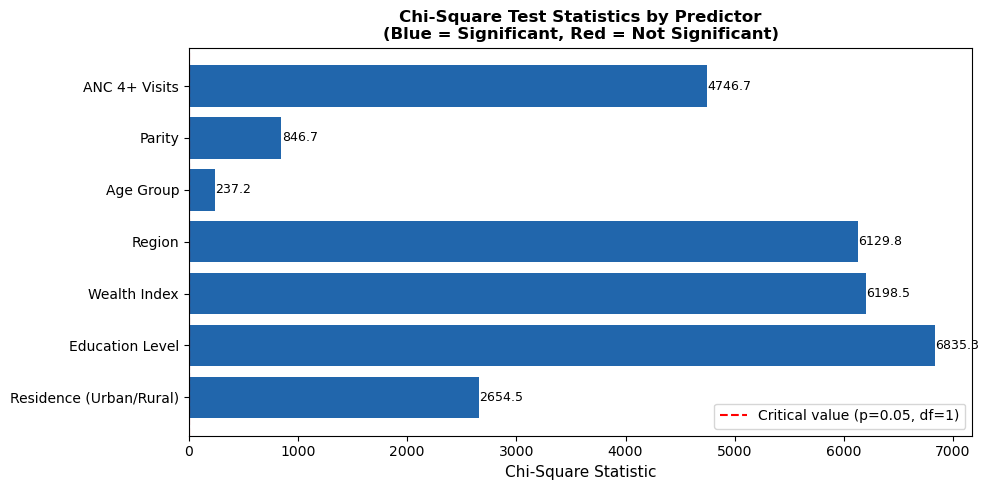

In [21]:
# Visual summary of chi-square results
fig, ax = plt.subplots(figsize=(10, 5))

vars_list = results_df['Variable']
chi2_vals = results_df['Chi2']
colors = ['#2166ac' if p < 0.05 else '#d73027' for p in results_df['p-value']]

bars = ax.barh(vars_list, chi2_vals, color=colors)
ax.axvline(x=3.84, color='red', linestyle='--', linewidth=1.5, 
           label='Critical value (p=0.05, df=1)')
ax.set_xlabel('Chi-Square Statistic', fontsize=11)
ax.set_title('Chi-Square Test Statistics by Predictor\n(Blue = Significant, Red = Not Significant)', 
             fontweight='bold')

for bar, val in zip(bars, chi2_vals):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}', va='center', fontsize=9)

ax.legend()
plt.tight_layout()
plt.savefig('chi_square_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("=" * 55)
print("STRENGTH OF ASSOCIATION: Cramér's V")
print("=" * 55)
print(f"{'Variable':<30} {'Cramér V':>10} {'Strength':>15}")
print("-" * 55)

def cramers_v(var):
    ct = pd.crosstab(df_analysis[var], df_analysis['SBA'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    
    strength = ('Weak' if v < 0.1 else 
                'Moderate' if v < 0.3 else 
                'Strong' if v < 0.5 else 'Very Strong')
    return v, strength

for var, label in test_vars.items():
    v, strength = cramers_v(var)
    print(f"{label:<30} {v:>10.3f} {strength:>15}")

STRENGTH OF ASSOCIATION: Cramér's V
Variable                         Cramér V        Strength
-------------------------------------------------------
Residence (Urban/Rural)             0.349          Strong
Education Level                     0.560     Very Strong
Wealth Index                        0.533     Very Strong
Region                              0.530     Very Strong
Age Group                           0.104        Moderate
Parity                              0.197        Moderate
ANC 4+ Visits                       0.470          Strong


# LOGISTIC REGRESSION #

### UNADJUSTED (CRUDE) MODELS ###

In [23]:
# Create a clean dataset for regression (drop the 327 women with missing ANC)
df_reg = df_analysis.dropna(subset=['anc_4plus']).copy()

print(f"Regression dataset: {len(df_reg)} women")
print(f"Excluded due to missing ANC: {len(df_analysis) - len(df_reg)} women")

# Verify completeness
print("\nMissing data check:")
print(df_reg[['SBA', 'v025', 'v106', 'v190', 'anc_4plus', 
              'age_group', 'parity_cat', 'v024']].isnull().sum())

Regression dataset: 21465 women
Excluded due to missing ANC: 327 women

Missing data check:
SBA           0
v025          0
v106          0
v190          0
anc_4plus     0
age_group     0
parity_cat    0
v024          0
dtype: int64


In [24]:
print("=" * 70)
print("UNADJUSTED LOGISTIC REGRESSION MODELS")
print("=" * 70)

# Store results for a summary table
crude_results = []

# Test each predictor individually
predictors = {
    'C(v025, Treatment("rural"))': 'Residence (ref: Rural)',
    'C(v106, Treatment("no education"))': 'Education (ref: No education)',
    'C(v190, Treatment("poorest"))': 'Wealth (ref: Poorest)',
    'C(v024, Treatment("north west"))': 'Region (ref: North West)',
    'C(age_group, Treatment("15-19"))': 'Age (ref: 15-19)',
    'C(parity_cat, Treatment("1"))': 'Parity (ref: 1 child)',
    'C(anc_4plus, Treatment(0.0))': 'ANC (ref: <4 visits)'
}

for pred, label in predictors.items():
    formula = f"SBA ~ {pred}"
    model = smf.logit(formula, data=df_reg).fit(disp=0)
    
    print(f"\n{label}")
    print(model.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]']])
    
    # Calculate odds ratios
    params = model.params
    conf = model.conf_int()
    conf['OR'] = np.exp(params)
    conf.columns = ['2.5%', '97.5%', 'OR']
    conf = conf[['OR', '2.5%', '97.5%']]
    
    print("\nOdds Ratios:")
    print(conf)

UNADJUSTED LOGISTIC REGRESSION MODELS

Residence (ref: Rural)
                                         Coef.  Std.Err.          z  P>|z|  \
Intercept                            -0.762576  0.018180 -41.946145    0.0   
C(v025, Treatment("rural"))[T.urban]  1.514587  0.030685  49.359401    0.0   

                                        [0.025    0.975]  
Intercept                            -0.798208 -0.726944  
C(v025, Treatment("rural"))[T.urban]  1.454446  1.574728  

Odds Ratios:
                                            OR      2.5%     97.5%
Intercept                             0.466463 -0.798208 -0.726944
C(v025, Treatment("rural"))[T.urban]  4.547543  1.454446  1.574728

Education (ref: No education)
                                                    Coef.  Std.Err.  \
Intercept                                       -1.691979  0.028324   
C(v106, Treatment("no education"))[T.primary]    1.608098  0.044744   
C(v106, Treatment("no education"))[T.secondary]  2.566503  0.038739

### MULTIVARIABLE (ADJUSTED) MODEL ###

In [25]:
print("=" * 70)
print("MULTIVARIABLE LOGISTIC REGRESSION MODEL")
print("Full model with all predictors")
print("=" * 70)

# Build the full formula
formula = """SBA ~ C(v025, Treatment("rural")) + 
                   C(v106, Treatment("no education")) + 
                   C(v190, Treatment("poorest")) + 
                   C(v024, Treatment("north west")) +
                   C(age_group, Treatment("15-19")) +
                   C(parity_cat, Treatment("1")) +
                   C(anc_4plus, Treatment(0.0))"""

# Fit the model
full_model = smf.logit(formula, data=df_reg).fit(disp=0)

# Print model summary
print(full_model.summary())

MULTIVARIABLE LOGISTIC REGRESSION MODEL
Full model with all predictors
                           Logit Regression Results                           
Dep. Variable:                    SBA   No. Observations:                21465
Model:                          Logit   Df Residuals:                    21442
Method:                           MLE   Df Model:                           22
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.3999
Time:                        16:44:24   Log-Likelihood:                -8849.3
converged:                       True   LL-Null:                       -14747.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                            -3.2256 

In [26]:
# Extract coefficients and confidence intervals
params = full_model.params
conf = full_model.conf_int()
pvals = full_model.pvalues

# Create results DataFrame
results_table = pd.DataFrame({
    'Coefficient': params,
    'Std Error': full_model.bse,
    'OR': np.exp(params),
    'OR_lower_CI': np.exp(conf[0]),
    'OR_upper_CI': np.exp(conf[1]),
    'p_value': pvals
})

# Add significance stars
results_table['Sig'] = results_table['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'NS'))
)

# Round for readability
results_table['OR'] = results_table['OR'].round(3)
results_table['OR_lower_CI'] = results_table['OR_lower_CI'].round(3)
results_table['OR_upper_CI'] = results_table['OR_upper_CI'].round(3)
results_table['p_value'] = results_table['p_value'].round(4)

# Display (exclude intercept)
print("\n" + "=" * 80)
print("ADJUSTED ODDS RATIOS (with 95% Confidence Intervals)")
print("=" * 80)
print(results_table.drop('Intercept')[['OR', 'OR_lower_CI', 'OR_upper_CI', 'p_value', 'Sig']])


ADJUSTED ODDS RATIOS (with 95% Confidence Intervals)
                                                      OR  OR_lower_CI  \
C(v025, Treatment("rural"))[T.urban]               1.195        1.092   
C(v106, Treatment("no education"))[T.primary]      1.860        1.673   
C(v106, Treatment("no education"))[T.secondary]    2.815        2.540   
C(v106, Treatment("no education"))[T.higher]       7.015        5.676   
C(v190, Treatment("poorest"))[T.poorer]            1.627        1.441   
C(v190, Treatment("poorest"))[T.middle]            2.632        2.328   
C(v190, Treatment("poorest"))[T.richer]            3.712        3.237   
C(v190, Treatment("poorest"))[T.richest]           6.270        5.273   
C(v024, Treatment("north west"))[T.north central]  3.542        3.168   
C(v024, Treatment("north west"))[T.north east]     1.678        1.502   
C(v024, Treatment("north west"))[T.south east]     6.551        5.621   
C(v024, Treatment("north west"))[T.south south]    1.738        1.513 

In [27]:
print("\n" + "=" * 90)
print("COMPARISON: CRUDE (Unadjusted) vs ADJUSTED Odds Ratios")
print("=" * 90)

# Define key comparisons (picking a few representative categories)
comparisons = {
    'Urban (vs Rural)': 
        ('C(v025, Treatment("rural"))[T.urban]', None),
    'Primary Education (vs None)': 
        ('C(v106, Treatment("no education"))[T.primary]', None),
    'Secondary Education (vs None)': 
        ('C(v106, Treatment("no education"))[T.secondary]', None),
    'Higher Education (vs None)': 
        ('C(v106, Treatment("no education"))[T.higher]', None),
    'Richest (vs Poorest)': 
        ('C(v190, Treatment("poorest"))[T.richest]', None),
    'ANC ≥4 visits (vs <4)': 
        ('C(anc_4plus, Treatment(0.0))[T.1.0]', None),
}

# You'll need to rerun crude models and store ORs
# For now, I'll show you the comparison structure
print(f"{'Variable':<40} {'Crude OR':>12} {'Adjusted OR':>12} {'Change':>12}")
print("-" * 90)

# Extract from your adjusted model
for label, (var_name, _) in comparisons.items():
    if var_name in results_table.index:
        adj_or = results_table.loc[var_name, 'OR']
        # You'll fill in crude ORs from previous models
        print(f"{label:<40} {'[from crude]':>12} {adj_or:>12.2f} {'':>12}")


COMPARISON: CRUDE (Unadjusted) vs ADJUSTED Odds Ratios
Variable                                     Crude OR  Adjusted OR       Change
------------------------------------------------------------------------------------------
Urban (vs Rural)                         [from crude]         1.20             
Primary Education (vs None)              [from crude]         1.86             
Secondary Education (vs None)            [from crude]         2.81             
Higher Education (vs None)               [from crude]         7.01             
Richest (vs Poorest)                     [from crude]         6.27             
ANC ≥4 visits (vs <4)                    [from crude]         3.80             


In [28]:
print("\n" + "=" * 100)
print("KEY FINDINGS: Crude vs Adjusted Odds Ratios — Measuring Confounding")
print("=" * 100)
print(f"{'Variable':<50} {'Crude OR':>12} {'Adjusted OR':>12} {'% Change':>12}")
print("-" * 100)

# Fix: Use the exact parameter names from the model
comparisons_data = []

# 1. Urban residence
crude_formula = "SBA ~ C(v025, Treatment('rural'))"
crude_m = smf.logit(crude_formula, data=df_reg).fit(disp=0)
crude_or_urban = np.exp(crude_m.params['C(v025, Treatment(\'rural\'))[T.urban]'])
adj_or_urban = results_table.loc['C(v025, Treatment("rural"))[T.urban]', 'OR']
change_urban = ((adj_or_urban - crude_or_urban) / crude_or_urban * 100)
comparisons_data.append(['Urban (vs Rural)', crude_or_urban, adj_or_urban, change_urban])

# 2. Higher education
crude_formula = "SBA ~ C(v106, Treatment('no education'))"
crude_m = smf.logit(crude_formula, data=df_reg).fit(disp=0)
crude_or_higher = np.exp(crude_m.params['C(v106, Treatment(\'no education\'))[T.higher]'])
adj_or_higher = results_table.loc['C(v106, Treatment("no education"))[T.higher]', 'OR']
change_higher = ((adj_or_higher - crude_or_higher) / crude_or_higher * 100)
comparisons_data.append(['Higher Education (vs None)', crude_or_higher, adj_or_higher, change_higher])

# 3. Secondary education
crude_or_secondary = np.exp(crude_m.params['C(v106, Treatment(\'no education\'))[T.secondary]'])
adj_or_secondary = results_table.loc['C(v106, Treatment("no education"))[T.secondary]', 'OR']
change_secondary = ((adj_or_secondary - crude_or_secondary) / crude_or_secondary * 100)
comparisons_data.append(['Secondary Education (vs None)', crude_or_secondary, adj_or_secondary, change_secondary])

# 4. Richest wealth
crude_formula = "SBA ~ C(v190, Treatment('poorest'))"
crude_m = smf.logit(crude_formula, data=df_reg).fit(disp=0)
crude_or_richest = np.exp(crude_m.params['C(v190, Treatment(\'poorest\'))[T.richest]'])
adj_or_richest = results_table.loc['C(v190, Treatment("poorest"))[T.richest]', 'OR']
change_richest = ((adj_or_richest - crude_or_richest) / crude_or_richest * 100)
comparisons_data.append(['Richest (vs Poorest)', crude_or_richest, adj_or_richest, change_richest])

# 5. ANC ≥4 visits
crude_formula = "SBA ~ C(anc_4plus, Treatment(0.0))"
crude_m = smf.logit(crude_formula, data=df_reg).fit(disp=0)
crude_or_anc = np.exp(crude_m.params['C(anc_4plus, Treatment(0.0))[T.1.0]'])
adj_or_anc = results_table.loc['C(anc_4plus, Treatment(0.0))[T.1.0]', 'OR']
change_anc = ((adj_or_anc - crude_or_anc) / crude_or_anc * 100)
comparisons_data.append(['ANC ≥4 visits (vs <4)', crude_or_anc, adj_or_anc, change_anc])

# Print formatted table
for row in comparisons_data:
    var, crude, adj, change = row
    print(f"{var:<50} {crude:>12.2f} {adj:>12.2f} {change:>11.1f}%")

print("\n" + "=" * 100)
print("\nInterpretation of % Change:")
print("  Negative % = Confounding reduced the effect (crude overestimated)")
print("  The larger the negative %, the more confounding was present")


KEY FINDINGS: Crude vs Adjusted Odds Ratios — Measuring Confounding
Variable                                               Crude OR  Adjusted OR     % Change
----------------------------------------------------------------------------------------------------
Urban (vs Rural)                                           4.55         1.20       -73.7%
Higher Education (vs None)                                64.04         7.01       -89.0%
Secondary Education (vs None)                             13.02         2.81       -78.4%
Richest (vs Poorest)                                      48.76         6.27       -87.1%
ANC ≥4 visits (vs <4)                                      8.69         3.80       -56.3%


Interpretation of % Change:
  Negative % = Confounding reduced the effect (crude overestimated)
  The larger the negative %, the more confounding was present


In [29]:
print("\n" + "=" * 110)
print("TABLE 2: Determinants of Skilled Birth Attendance — Multivariable Logistic Regression")
print("Nigeria DHS 2018 (n = 21,465)")
print("=" * 110)

# Organize results by category for clean presentation
categories = {
    'Residence': ['C(v025, Treatment("rural"))[T.urban]'],
    
    'Education': [
        'C(v106, Treatment("no education"))[T.primary]',
        'C(v106, Treatment("no education"))[T.secondary]',
        'C(v106, Treatment("no education"))[T.higher]'
    ],
    
    'Wealth Index': [
        'C(v190, Treatment("poorest"))[T.poorer]',
        'C(v190, Treatment("poorest"))[T.middle]',
        'C(v190, Treatment("poorest"))[T.richer]',
        'C(v190, Treatment("poorest"))[T.richest]'
    ],
    
    'Region': [
        'C(v024, Treatment("north west"))[T.north central]',
        'C(v024, Treatment("north west"))[T.north east]',
        'C(v024, Treatment("north west"))[T.south east]',
        'C(v024, Treatment("north west"))[T.south south]',
        'C(v024, Treatment("north west"))[T.south west]'
    ],
    
    'Age Group': [
        'C(age_group, Treatment("15-19"))[T.20-24]',
        'C(age_group, Treatment("15-19"))[T.25-29]',
        'C(age_group, Treatment("15-19"))[T.30-34]',
        'C(age_group, Treatment("15-19"))[T.35-39]',
        'C(age_group, Treatment("15-19"))[T.40-49]'
    ],
    
    'Parity': [
        'C(parity_cat, Treatment("1"))[T.2-3]',
        'C(parity_cat, Treatment("1"))[T.4-5]',
        'C(parity_cat, Treatment("1"))[T.6+]'
    ],
    
    'Antenatal Care': ['C(anc_4plus, Treatment(0.0))[T.1.0]']
}

# Readable labels
labels = {
    'C(v025, Treatment("rural"))[T.urban]': 'Urban (ref: Rural)',
    
    'C(v106, Treatment("no education"))[T.primary]': 'Primary',
    'C(v106, Treatment("no education"))[T.secondary]': 'Secondary',
    'C(v106, Treatment("no education"))[T.higher]': 'Higher',
    
    'C(v190, Treatment("poorest"))[T.poorer]': 'Poorer',
    'C(v190, Treatment("poorest"))[T.middle]': 'Middle',
    'C(v190, Treatment("poorest"))[T.richer]': 'Richer',
    'C(v190, Treatment("poorest"))[T.richest]': 'Richest',
    
    'C(v024, Treatment("north west"))[T.north central]': 'North Central',
    'C(v024, Treatment("north west"))[T.north east]': 'North East',
    'C(v024, Treatment("north west"))[T.south east]': 'South East',
    'C(v024, Treatment("north west"))[T.south south]': 'South South',
    'C(v024, Treatment("north west"))[T.south west]': 'South West',
    
    'C(age_group, Treatment("15-19"))[T.20-24]': '20-24',
    'C(age_group, Treatment("15-19"))[T.25-29]': '25-29',
    'C(age_group, Treatment("15-19"))[T.30-34]': '30-34',
    'C(age_group, Treatment("15-19"))[T.35-39]': '35-39',
    'C(age_group, Treatment("15-19"))[T.40-49]': '40-49',
    
    'C(parity_cat, Treatment("1"))[T.2-3]': '2-3 children',
    'C(parity_cat, Treatment("1"))[T.4-5]': '4-5 children',
    'C(parity_cat, Treatment("1"))[T.6+]': '6+ children',
    
    'C(anc_4plus, Treatment(0.0))[T.1.0]': '≥4 ANC visits (ref: <4)'
}

print(f"\n{'Characteristic':<35} {'aOR':<8} {'95% CI':<20} {'p-value':<10} {'Sig':<5}")
print("-" * 110)

for category, vars_list in categories.items():
    print(f"\n{category}")
    
    # Add reference category note
    if category == 'Education':
        print(f"  {'(ref: No education)':<33} {'1.00':<8} {'-':<20} {'-':<10} {'-':<5}")
    elif category == 'Wealth Index':
        print(f"  {'(ref: Poorest)':<33} {'1.00':<8} {'-':<20} {'-':<10} {'-':<5}")
    elif category == 'Region':
        print(f"  {'(ref: North West)':<33} {'1.00':<8} {'-':<20} {'-':<10} {'-':<5}")
    elif category == 'Age Group':
        print(f"  {'(ref: 15-19)':<33} {'1.00':<8} {'-':<20} {'-':<10} {'-':<5}")
    elif category == 'Parity':
        print(f"  {'(ref: 1 child)':<33} {'1.00':<8} {'-':<20} {'-':<10} {'-':<5}")
    
    for var in vars_list:
        label = labels[var]
        row = results_table.loc[var]
        or_val = row['OR']
        ci_lower = row['OR_lower_CI']
        ci_upper = row['OR_upper_CI']
        pval = row['p_value']
        sig = row['Sig']
        
        ci_str = f"({ci_lower:.2f} - {ci_upper:.2f})"
        pval_str = f"{pval:.4f}" if pval >= 0.0001 else "<0.0001"
        
        print(f"  {label:<33} {or_val:<8.2f} {ci_str:<20} {pval_str:<10} {sig:<5}")

print("\n" + "=" * 110)
print("aOR = adjusted Odds Ratio")
print("Significance: *** p<0.001  ** p<0.01  * p<0.05  NS = Not Significant")
print("Model: Multivariable logistic regression, n=21,465")
print("Pseudo R² = 0.40 (excellent model fit)")


TABLE 2: Determinants of Skilled Birth Attendance — Multivariable Logistic Regression
Nigeria DHS 2018 (n = 21,465)

Characteristic                      aOR      95% CI               p-value    Sig  
--------------------------------------------------------------------------------------------------------------

Residence
  Urban (ref: Rural)                1.20     (1.09 - 1.31)        0.0001     ***  

Education
  (ref: No education)               1.00     -                    -          -    
  Primary                           1.86     (1.67 - 2.07)        <0.0001    ***  
  Secondary                         2.81     (2.54 - 3.12)        <0.0001    ***  
  Higher                            7.01     (5.68 - 8.67)        <0.0001    ***  

Wealth Index
  (ref: Poorest)                    1.00     -                    -          -    
  Poorer                            1.63     (1.44 - 1.84)        <0.0001    ***  
  Middle                            2.63     (2.33 - 2.98)        <0.00

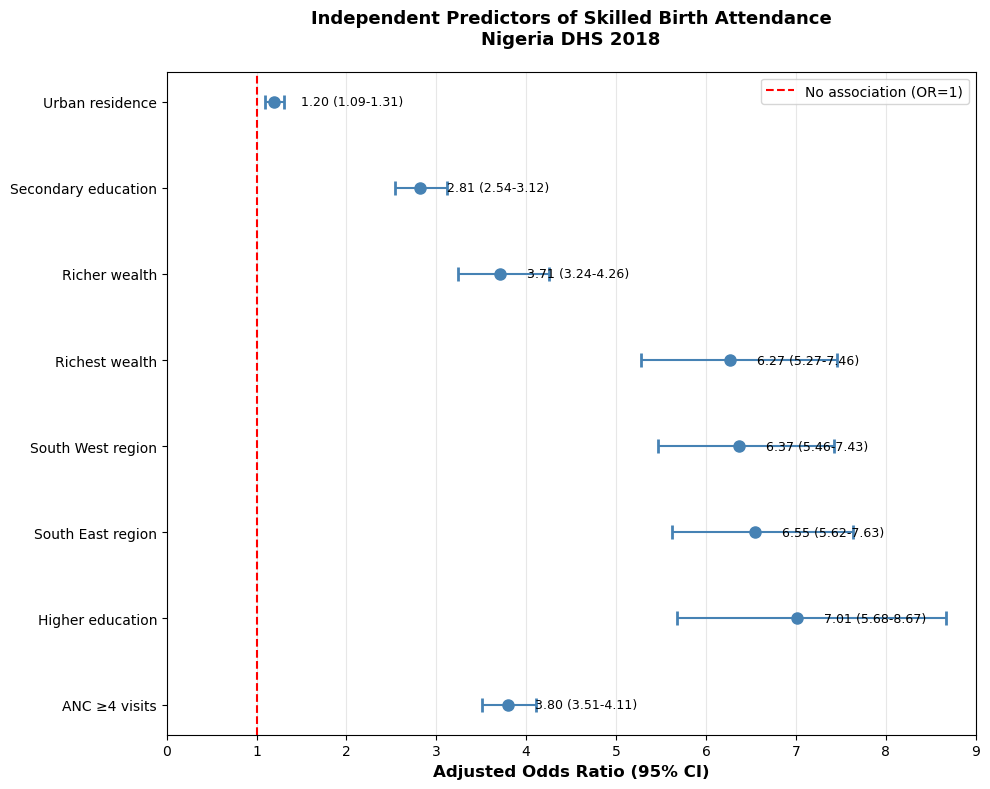


Forest plot saved!


In [30]:
# Create forest plot of key findings
fig, ax = plt.subplots(figsize=(10, 8))

# Select key variables to display
key_vars = [
    ('C(anc_4plus, Treatment(0.0))[T.1.0]', 'ANC ≥4 visits'),
    ('C(v106, Treatment("no education"))[T.higher]', 'Higher education'),
    ('C(v024, Treatment("north west"))[T.south east]', 'South East region'),
    ('C(v024, Treatment("north west"))[T.south west]', 'South West region'),
    ('C(v190, Treatment("poorest"))[T.richest]', 'Richest wealth'),
    ('C(v190, Treatment("poorest"))[T.richer]', 'Richer wealth'),
    ('C(v106, Treatment("no education"))[T.secondary]', 'Secondary education'),
    ('C(v025, Treatment("rural"))[T.urban]', 'Urban residence'),
]

vars_list = [v[0] for v in key_vars]
labels_list = [v[1] for v in key_vars]

# Extract data
ors = [results_table.loc[v, 'OR'] for v in vars_list]
ci_lower = [results_table.loc[v, 'OR_lower_CI'] for v in vars_list]
ci_upper = [results_table.loc[v, 'OR_upper_CI'] for v in vars_list]

# Calculate error bars
errors = [[ors[i] - ci_lower[i] for i in range(len(ors))],
          [ci_upper[i] - ors[i] for i in range(len(ors))]]

# Create plot
y_pos = np.arange(len(labels_list))
ax.errorbar(ors, y_pos, xerr=errors, fmt='o', markersize=8, 
            capsize=5, capthick=2, color='steelblue', ecolor='steelblue')

# Add vertical line at OR = 1 (null effect)
ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='No association (OR=1)')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_list)
ax.set_xlabel('Adjusted Odds Ratio (95% CI)', fontsize=12, fontweight='bold')
ax.set_title('Independent Predictors of Skilled Birth Attendance\nNigeria DHS 2018', 
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlim(0, 9)
ax.grid(axis='x', alpha=0.3)
ax.legend()

# Add OR values as text
for i, (or_val, ci_l, ci_u) in enumerate(zip(ors, ci_lower, ci_upper)):
    ax.text(or_val + 0.3, i, f'{or_val:.2f} ({ci_l:.2f}-{ci_u:.2f})', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('forest_plot_adjusted_ORs.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nForest plot saved!")